--- Original Dataset ---
  Student  Maths  Science
0       A      2        1
1       B      4        3
2       C      6        5
3       D      8        7
4       E     10        9


--- PCA Results ---
Explained Variance Ratio: 100.00%
PCA Component (Eigenvector): [[0.70710678 0.70710678]]

Dataset with Principal Component 1 (PC1):
  Student  Maths  Science       PC1
0       A      2        1 -5.656854
1       B      4        3 -2.828427
2       C      6        5  0.000000
3       D      8        7  2.828427
4       E     10        9  5.656854


--- Simple Linear Regression (Maths -> Science) ---
Slope (b1): 1.0000
Intercept (b0): -1.0000
Equation: Science = 1.00 * Maths + (-1.00)
R2 Score: 1.0000


--- Regression using Principal Component (PC1 -> Total Score) ---
Slope: 1.4142
Intercept: 11.0000
Equation: Total_Score = 11.00 + 1.4142 * PC1
R2 Score: 1.0000


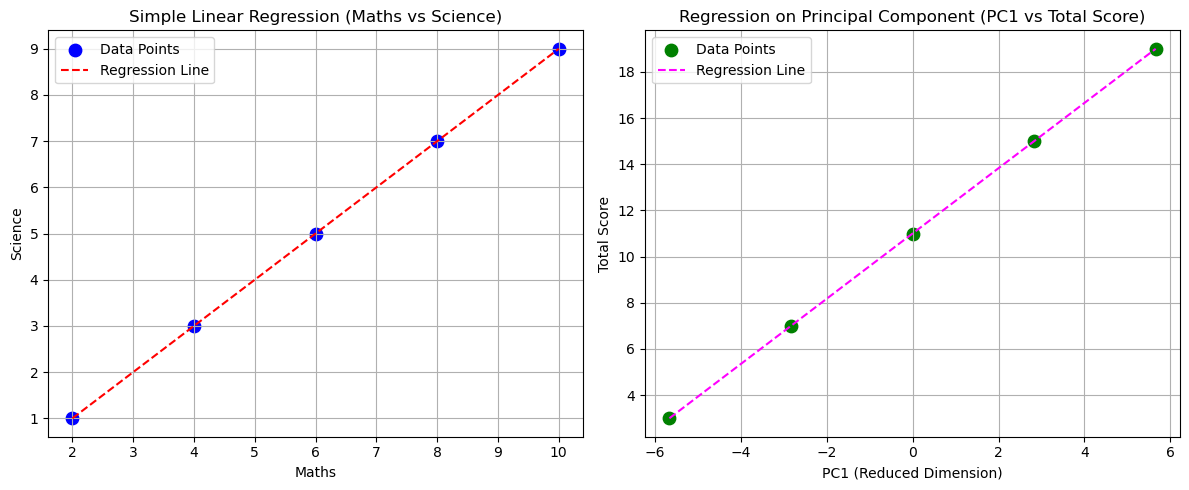

In [1]:
# First Problem

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ==========================================
# 1. Dataset Setup
# ==========================================
data = {
    'Student': ['A', 'B', 'C', 'D', 'E'],
    'Maths': [2, 4, 6, 8, 10],
    'Science': [1, 3, 5, 7, 9]
}
df = pd.DataFrame(data)
X = df[['Maths', 'Science']]

print("--- Original Dataset ---")
print(df)
print("\n" + "="*50 + "\n")

# ==========================================
# 2. Dimensionality Reduction using PCA
# ==========================================
# Initialize PCA to reduce 2 features -> 1 component
pca = PCA(n_components=1)
PC1 = pca.fit_transform(X)

df['PC1'] = PC1

print("--- PCA Results ---")
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PCA Component (Eigenvector): {pca.components_}")
print("\nDataset with Principal Component 1 (PC1):")
print(df[['Student', 'Maths', 'Science', 'PC1']])
print("\n" + "="*50 + "\n")

# ==========================================
# 3. Simple Linear Regression (Maths -> Science)
# ==========================================
X_simple = df[['Maths']]
y_simple = df['Science']

slr_model = LinearRegression()
slr_model.fit(X_simple, y_simple)
y_pred_slr = slr_model.predict(X_simple)

print("--- Simple Linear Regression (Maths -> Science) ---")
print(f"Slope (b1): {slr_model.coef_[0]:.4f}")
print(f"Intercept (b0): {slr_model.intercept_:.4f}")
print(f"Equation: Science = {slr_model.coef_[0]:.2f} * Maths + ({slr_model.intercept_:.2f})")
print(f"R2 Score: {r2_score(y_simple, y_pred_slr):.4f}")
print("\n" + "="*50 + "\n")

# ==========================================
# 4. Multiple / PCA Regression (PC1 -> Total Score)
# ==========================================
# Let's define a target outcome (Total Marks)
df['Total_Score'] = df['Maths'] + df['Science']
y_multi = df['Total_Score']
X_pca = df[['PC1']]

pcr_model = LinearRegression()
pcr_model.fit(X_pca, y_multi)
y_pred_pcr = pcr_model.predict(X_pca)

print("--- Regression using Principal Component (PC1 -> Total Score) ---")
print(f"Slope: {pcr_model.coef_[0]:.4f}")
print(f"Intercept: {pcr_model.intercept_:.4f}")
print(f"Equation: Total_Score = {pcr_model.intercept_:.2f} + {pcr_model.coef_[0]:.4f} * PC1")
print(f"R2 Score: {r2_score(y_multi, y_pred_pcr):.4f}")

# ==========================================
# 5. Visualization
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Simple Linear Regression
axes[0].scatter(df['Maths'], df['Science'], color='blue', s=80, label='Data Points')
axes[0].plot(df['Maths'], y_pred_slr, color='red', linestyle='--', label='Regression Line')
axes[0].set_title('Simple Linear Regression (Maths vs Science)')
axes[0].set_xlabel('Maths')
axes[0].set_ylabel('Science')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Regression on PC1
axes[1].scatter(df['PC1'], df['Total_Score'], color='green', s=80, label='Data Points')
axes[1].plot(df['PC1'], y_pred_pcr, color='magenta', linestyle='--', label='Regression Line')
axes[1].set_title('Regression on Principal Component (PC1 vs Total Score)')
axes[1].set_xlabel('PC1 (Reduced Dimension)')
axes[1].set_ylabel('Total Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

--- Original Dataset ---
  Student  X1_StudyHours  Science
0       A              2        3
1       B              4        5
2       C              5        8
3       D              7       10
4       E              9       12


--- PCA Results ---
Explained Variance Ratio: 99.29%
Eigenvector (PC1 components): [0.59351928 0.80481977]

Data with Principal Component 1 (PC1):
  Student  X1_StudyHours  Science       PC1
0       A              2        3 -5.720136
1       B              4        5 -2.923458
2       C              5        8  0.084520
3       D              7       10  2.881198
4       E              9       12  5.677876


--- Simple Linear Regression (Study Hours -> Science Marks) ---
Slope (b1): 1.3288
Intercept (b0): 0.4247
Equation: Science = 1.3288 * X1 + (0.4247)
R2 Score: 0.9691


--- Regression using Principal Component (PC1 -> Total Score) ---
Slope (b1): 1.3983
Intercept (b0): 13.0000
Equation: Total_Score = 13.0000 + 1.3983 * PC1
R2 Score: 0.9998


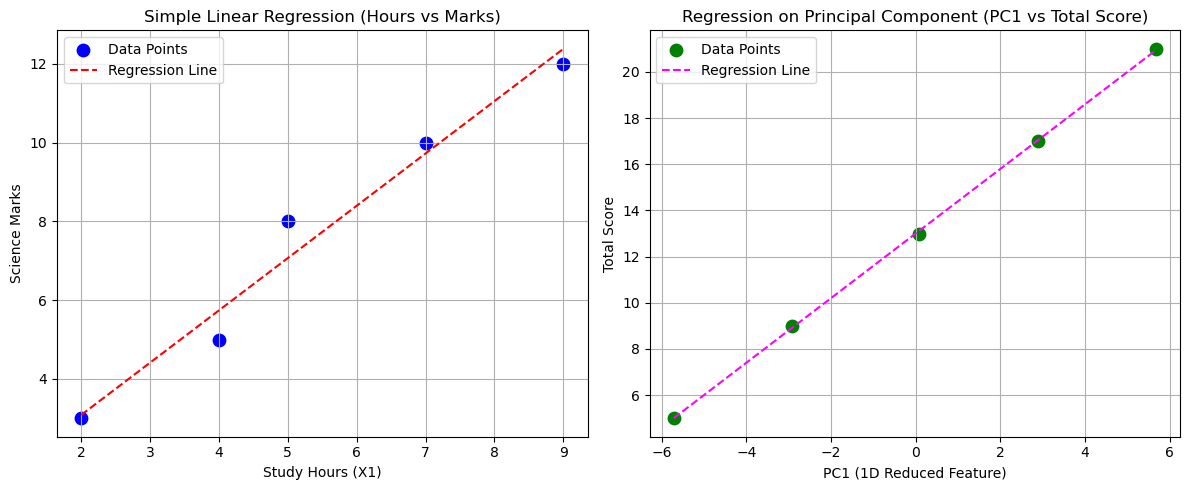

In [2]:
# second problem

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ==========================================
# 1. Dataset Setup
# ==========================================
data = {
    'Student': ['A', 'B', 'C', 'D', 'E'],
    'X1_StudyHours': [2, 4, 5, 7, 9],
    'Science': [3, 5, 8, 10, 12]
}
df = pd.DataFrame(data)
X = df[['X1_StudyHours', 'Science']]

print("--- Original Dataset ---")
print(df)
print("\n" + "="*50 + "\n")

# ==========================================
# 2. PCA: Reduce 2D -> 1D
# ==========================================
pca = PCA(n_components=1)
df['PC1'] = pca.fit_transform(X)

print("--- PCA Results ---")
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Eigenvector (PC1 components): {pca.components_[0]}")
print("\nData with Principal Component 1 (PC1):")
print(df[['Student', 'X1_StudyHours', 'Science', 'PC1']])
print("\n" + "="*50 + "\n")

# ==========================================
# 3. Simple Linear Regression (X1 -> Science)
# ==========================================
X_slr = df[['X1_StudyHours']]
y_slr = df['Science']

slr_model = LinearRegression()
slr_model.fit(X_slr, y_slr)
y_pred_slr = slr_model.predict(X_slr)

print("--- Simple Linear Regression (Study Hours -> Science Marks) ---")
print(f"Slope (b1): {slr_model.coef_[0]:.4f}")
print(f"Intercept (b0): {slr_model.intercept_:.4f}")
print(f"Equation: Science = {slr_model.coef_[0]:.4f} * X1 + ({slr_model.intercept_:.4f})")
print(f"R2 Score: {r2_score(y_slr, y_pred_slr):.4f}")
print("\n" + "="*50 + "\n")

# ==========================================
# 4. Regression using PC1
# ==========================================
df['Total_Score'] = df['X1_StudyHours'] + df['Science']
X_pcr = df[['PC1']]
y_pcr = df['Total_Score']

pcr_model = LinearRegression()
pcr_model.fit(X_pcr, y_pcr)
y_pred_pcr = pcr_model.predict(X_pcr)

print("--- Regression using Principal Component (PC1 -> Total Score) ---")
print(f"Slope (b1): {pcr_model.coef_[0]:.4f}")
print(f"Intercept (b0): {pcr_model.intercept_:.4f}")
print(f"Equation: Total_Score = {pcr_model.intercept_:.4f} + {pcr_model.coef_[0]:.4f} * PC1")
print(f"R2 Score: {r2_score(y_pcr, y_pred_pcr):.4f}")

# ==========================================
# 5. Visualization
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Simple Linear Regression
axes[0].scatter(df['X1_StudyHours'], df['Science'], color='blue', s=80, label='Data Points')
axes[0].plot(df['X1_StudyHours'], y_pred_slr, color='red', linestyle='--', label='Regression Line')
axes[0].set_title('Simple Linear Regression (Hours vs Marks)')
axes[0].set_xlabel('Study Hours (X1)')
axes[0].set_ylabel('Science Marks')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Regression on PC1
axes[1].scatter(df['PC1'], df['Total_Score'], color='green', s=80, label='Data Points')
axes[1].plot(df['PC1'], y_pred_pcr, color='magenta', linestyle='--', label='Regression Line')
axes[1].set_title('Regression on Principal Component (PC1 vs Total Score)')
axes[1].set_xlabel('PC1 (1D Reduced Feature)')
axes[1].set_ylabel('Total Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [3]:
# third problem

import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

# -----------------------------------
# Dataset
# -----------------------------------
students = ['A', 'B', 'C', 'D', 'E']

study_hours = [2, 4, 5, 7, 9]
science_marks = [3, 5, 8, 10, 12]

df = pd.DataFrame({
    'Student': students,
    'Study_Hours': study_hours,
    'Science_Marks': science_marks
})

print("Original Dataset")
print(df)

# -----------------------------------
# PCA (2D -> 1D)
# -----------------------------------
X = df[['Study_Hours', 'Science_Marks']]

pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

df['PCA_1D'] = X_pca

print("\nDataset after PCA (2D -> 1D)")
print(df)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# -----------------------------------
# Simple Linear Regression
# Predict Science Marks using Study Hours
# -----------------------------------
X_simple = np.array(study_hours).reshape(-1, 1)
y = np.array(science_marks)

simple_model = LinearRegression()
simple_model.fit(X_simple, y)

print("\nSimple Linear Regression")
print("Slope (m):", simple_model.coef_[0])
print("Intercept (c):", simple_model.intercept_)

predictions = simple_model.predict(X_simple)

print("\nPredicted Science Marks")
for s, pred in zip(students, predictions):
    print(s, ":", round(pred, 2))

# -----------------------------------
# Multiple Linear Regression
# Target = Total Score
# Features = Study Hours + Science Marks
# -----------------------------------
total_score = [5, 9, 13, 17, 21]

X_multi = df[['Study_Hours', 'Science_Marks']]
y_multi = total_score

multi_model = LinearRegression()
multi_model.fit(X_multi, y_multi)

print("\nMultiple Linear Regression")
print("Coefficients:", multi_model.coef_)
print("Intercept:", multi_model.intercept_)

multi_predictions = multi_model.predict(X_multi)

print("\nPredicted Total Scores")
for s, pred in zip(students, multi_predictions):
    print(s, ":", round(pred, 2))

Original Dataset
  Student  Study_Hours  Science_Marks
0       A            2              3
1       B            4              5
2       C            5              8
3       D            7             10
4       E            9             12

Dataset after PCA (2D -> 1D)
  Student  Study_Hours  Science_Marks    PCA_1D
0       A            2              3 -5.720136
1       B            4              5 -2.923458
2       C            5              8  0.084520
3       D            7             10  2.881198
4       E            9             12  5.677876

Explained Variance Ratio:
[0.99287983]

Simple Linear Regression
Slope (m): 1.3287671232876712
Intercept (c): 0.4246575342465748

Predicted Science Marks
A : 3.08
B : 5.74
C : 7.07
D : 9.73
E : 12.38

Multiple Linear Regression
Coefficients: [1. 1.]
Intercept: -1.7763568394002505e-15

Predicted Total Scores
A : 5.0
B : 9.0
C : 13.0
D : 17.0
E : 21.0
